In [1]:
# Qwen Blockwise-ControlNet Inpaint Inference
#
# - Base models: /mnt/lica-data-2/for_jjseol/diffsynth_models/Qwen
# - ControlNet checkpoint: shared train output (latest step or manual)
# - Inference sample: one record from validation jsonl (single-sample demo)

In [1]:
from pathlib import Path
import json
import glob

import torch
from PIL import Image
from IPython.display import display

from diffsynth.pipelines.qwen_image import QwenImagePipeline, ModelConfig, ControlNetInput

SHARED_MODEL_ROOT = Path("/mnt/lica-data-2/for_jjseol/diffsynth_models")
QWEN_ROOT = SHARED_MODEL_ROOT / "Qwen"

DATASET_ROOT = Path("/home/ubuntu/for_jjseol/qwen_eraser_dataset")
VAL_JSONL_PATH = DATASET_ROOT / "val_blockwise_controlnet_inpaint.jsonl"
VAL_SAMPLE_INDEX = 1

# Checkpoint selection
CONTROLNET_CKPT_GLOB = str(SHARED_MODEL_ROOT / "train/Qwen-Image-Blockwise-ControlNet-Inpaint_full/step-*.safetensors")
PREFER_LATEST_TRAINED_CHECKPOINT = True
MANUAL_CONTROLNET_CKPT = SHARED_MODEL_ROOT / "train/Qwen-Image-Blockwise-ControlNet-Inpaint_full/step-30000.safetensors"

NEGATIVE_PROMPT = ""
NUM_INFERENCE_STEPS = 40
CFG_SCALE = 4.0
SEED = 0
CUDA_DEVICE_INDEX = 0
MAX_LONG_SIDE = 1024  # resize model input so long side is at most this value

if not VAL_JSONL_PATH.exists():
    raise FileNotFoundError(f"Validation jsonl not found: {VAL_JSONL_PATH}")

with open(VAL_JSONL_PATH, "r", encoding="utf-8") as f:
    val_records = [json.loads(line) for line in f if line.strip()]

if not val_records:
    raise ValueError(f"No validation records found: {VAL_JSONL_PATH}")
if not (0 <= VAL_SAMPLE_INDEX < len(val_records)):
    raise IndexError(f"VAL_SAMPLE_INDEX out of range: {VAL_SAMPLE_INDEX} (0..{len(val_records)-1})")

sample = val_records[VAL_SAMPLE_INDEX]
PROMPT = sample["prompt"]
INPUT_IMAGE_PATH = DATASET_ROOT / sample["blockwise_controlnet_image"]
MASK_IMAGE_PATH = DATASET_ROOT / sample["blockwise_controlnet_inpaint_mask"]
TARGET_IMAGE_PATH = DATASET_ROOT / sample["image"]

checkpoints = sorted(glob.glob(CONTROLNET_CKPT_GLOB))
if PREFER_LATEST_TRAINED_CHECKPOINT:
    if not checkpoints:
        raise FileNotFoundError(f"No trained checkpoint found: {CONTROLNET_CKPT_GLOB}")
    TRAINED_CONTROLNET_PATH = Path(checkpoints[-1])
else:
    TRAINED_CONTROLNET_PATH = MANUAL_CONTROLNET_CKPT

required_patterns = {
    "Qwen-Image transformer": str(QWEN_ROOT / "Qwen-Image/transformer/diffusion_pytorch_model*.safetensors"),
    "Qwen-Image text_encoder": str(QWEN_ROOT / "Qwen-Image/text_encoder/model*.safetensors"),
    "Qwen-Image vae": str(QWEN_ROOT / "Qwen-Image/vae/diffusion_pytorch_model.safetensors"),
    "Qwen-Image tokenizer": str(QWEN_ROOT / "Qwen-Image/tokenizer/*"),
}
missing = [name for name, pattern in required_patterns.items() if len(glob.glob(pattern)) == 0]
for path_name, path_value in [
    ("trained controlnet checkpoint", TRAINED_CONTROLNET_PATH),
    ("input image", INPUT_IMAGE_PATH),
    ("inpaint mask", MASK_IMAGE_PATH),
]:
    if not Path(path_value).exists():
        missing.append(f"{path_name}: {path_value}")

if missing:
    raise FileNotFoundError("Missing required files:\n- " + "\n- ".join(missing))

if torch.cuda.is_available():
    torch.cuda.set_device(CUDA_DEVICE_INDEX)
    device = f"cuda:{CUDA_DEVICE_INDEX}"
    torch_dtype = torch.bfloat16
else:
    device = "cpu"
    torch_dtype = torch.float32

print(f"[device] {device}")
print(f"[sample] index={VAL_SAMPLE_INDEX} / total={len(val_records)}")
print(f"[prompt] {PROMPT}")
print(f"[input] {INPUT_IMAGE_PATH}")
print(f"[mask] {MASK_IMAGE_PATH}")
print(f"[target] {TARGET_IMAGE_PATH}")
print(f"[controlnet ckpt] {TRAINED_CONTROLNET_PATH}")

[device] cuda:0
[sample] index=1 / total=11812
[prompt] [TASK_ERASE] Remove masked object and fill naturally.
[input] /home/ubuntu/for_jjseol/qwen_eraser_dataset/inputs/yqCKtlwbt7LX9WDGQH2z_00_src.png
[mask] /home/ubuntu/for_jjseol/qwen_eraser_dataset/blockwise_masks/val/00006402_yqCKtlwbt7LX9WDGQH2z_00_src_mask_bw.png
[target] /home/ubuntu/for_jjseol/qwen_eraser_dataset/targets/yqCKtlwbt7LX9WDGQH2z_00_erased.png
[controlnet ckpt] /mnt/lica-data-2/for_jjseol/diffsynth_models/train/Qwen-Image-Blockwise-ControlNet-Inpaint_full/step-30000.safetensors


In [2]:
def _model_config_from_glob(local_glob: str, label: str) -> ModelConfig:
    paths = sorted(glob.glob(local_glob))
    if not paths:
        raise FileNotFoundError(f"Missing local weights for {label}: {local_glob}")
    path_value = paths if len(paths) > 1 else paths[0]
    print(f"[model] {label}: {path_value}")
    return ModelConfig(path=path_value)


def _dir_config(path: Path, label: str) -> ModelConfig:
    if not path.exists():
        raise FileNotFoundError(f"Missing local directory for {label}: {path}")
    print(f"[aux] {label}: {path}")
    return ModelConfig(path=str(path))


pipe = QwenImagePipeline.from_pretrained(
    torch_dtype=torch_dtype,
    device=device,
    model_configs=[
        _model_config_from_glob(
            str(QWEN_ROOT / "Qwen-Image/transformer/diffusion_pytorch_model*.safetensors"),
            "Qwen-Image transformer",
        ),
        _model_config_from_glob(
            str(QWEN_ROOT / "Qwen-Image/text_encoder/model*.safetensors"),
            "Qwen-Image text encoder",
        ),
        _model_config_from_glob(
            str(QWEN_ROOT / "Qwen-Image/vae/diffusion_pytorch_model.safetensors"),
            "Qwen-Image vae",
        ),
        ModelConfig(path=str(TRAINED_CONTROLNET_PATH)),
    ],
    tokenizer_config=_dir_config(QWEN_ROOT / "Qwen-Image/tokenizer", "Qwen-Image tokenizer"),
    processor_config=None,
)

[model] Qwen-Image transformer: ['/mnt/lica-data-2/for_jjseol/diffsynth_models/Qwen/Qwen-Image/transformer/diffusion_pytorch_model-00001-of-00009.safetensors', '/mnt/lica-data-2/for_jjseol/diffsynth_models/Qwen/Qwen-Image/transformer/diffusion_pytorch_model-00002-of-00009.safetensors', '/mnt/lica-data-2/for_jjseol/diffsynth_models/Qwen/Qwen-Image/transformer/diffusion_pytorch_model-00003-of-00009.safetensors', '/mnt/lica-data-2/for_jjseol/diffsynth_models/Qwen/Qwen-Image/transformer/diffusion_pytorch_model-00004-of-00009.safetensors', '/mnt/lica-data-2/for_jjseol/diffsynth_models/Qwen/Qwen-Image/transformer/diffusion_pytorch_model-00005-of-00009.safetensors', '/mnt/lica-data-2/for_jjseol/diffsynth_models/Qwen/Qwen-Image/transformer/diffusion_pytorch_model-00006-of-00009.safetensors', '/mnt/lica-data-2/for_jjseol/diffsynth_models/Qwen/Qwen-Image/transformer/diffusion_pytorch_model-00007-of-00009.safetensors', '/mnt/lica-data-2/for_jjseol/diffsynth_models/Qwen/Qwen-Image/transformer/diff

Loaded model: {
    "model_name": "qwen_image_dit",
    "model_class": "diffsynth.models.qwen_image_dit.QwenImageDiT",
    "extra_kwargs": null
}
Loading models from: [
    "/mnt/lica-data-2/for_jjseol/diffsynth_models/Qwen/Qwen-Image/text_encoder/model-00001-of-00004.safetensors",
    "/mnt/lica-data-2/for_jjseol/diffsynth_models/Qwen/Qwen-Image/text_encoder/model-00002-of-00004.safetensors",
    "/mnt/lica-data-2/for_jjseol/diffsynth_models/Qwen/Qwen-Image/text_encoder/model-00003-of-00004.safetensors",
    "/mnt/lica-data-2/for_jjseol/diffsynth_models/Qwen/Qwen-Image/text_encoder/model-00004-of-00004.safetensors"
]
Loaded model: {
    "model_name": "qwen_image_text_encoder",
    "model_class": "diffsynth.models.qwen_image_text_encoder.QwenImageTextEncoder",
    "extra_kwargs": null
}
Loading models from: "/mnt/lica-data-2/for_jjseol/diffsynth_models/Qwen/Qwen-Image/vae/diffusion_pytorch_model.safetensors"
Loaded model: {
    "model_name": "qwen_image_vae",
    "model_class": "diffsy

In [7]:
VAL_SAMPLE_INDEX+=1
sample = val_records[VAL_SAMPLE_INDEX]
PROMPT = sample["prompt"]
INPUT_IMAGE_PATH = DATASET_ROOT / sample["blockwise_controlnet_image"]
MASK_IMAGE_PATH = DATASET_ROOT / sample["blockwise_controlnet_inpaint_mask"]
TARGET_IMAGE_PATH = DATASET_ROOT / sample["image"]

  0%|          | 0/40 [00:00<?, ?it/s]

100%|██████████| 40/40 [00:21<00:00,  1.86it/s]


[saved] /home/ubuntu/DiffSynth-Studio/output/qwen_blockwise_controlnet_inpaint/val_00004_step-30000.png
[saved preview] /home/ubuntu/DiffSynth-Studio/output/qwen_blockwise_controlnet_inpaint/val_00004_step-30000_preview.png


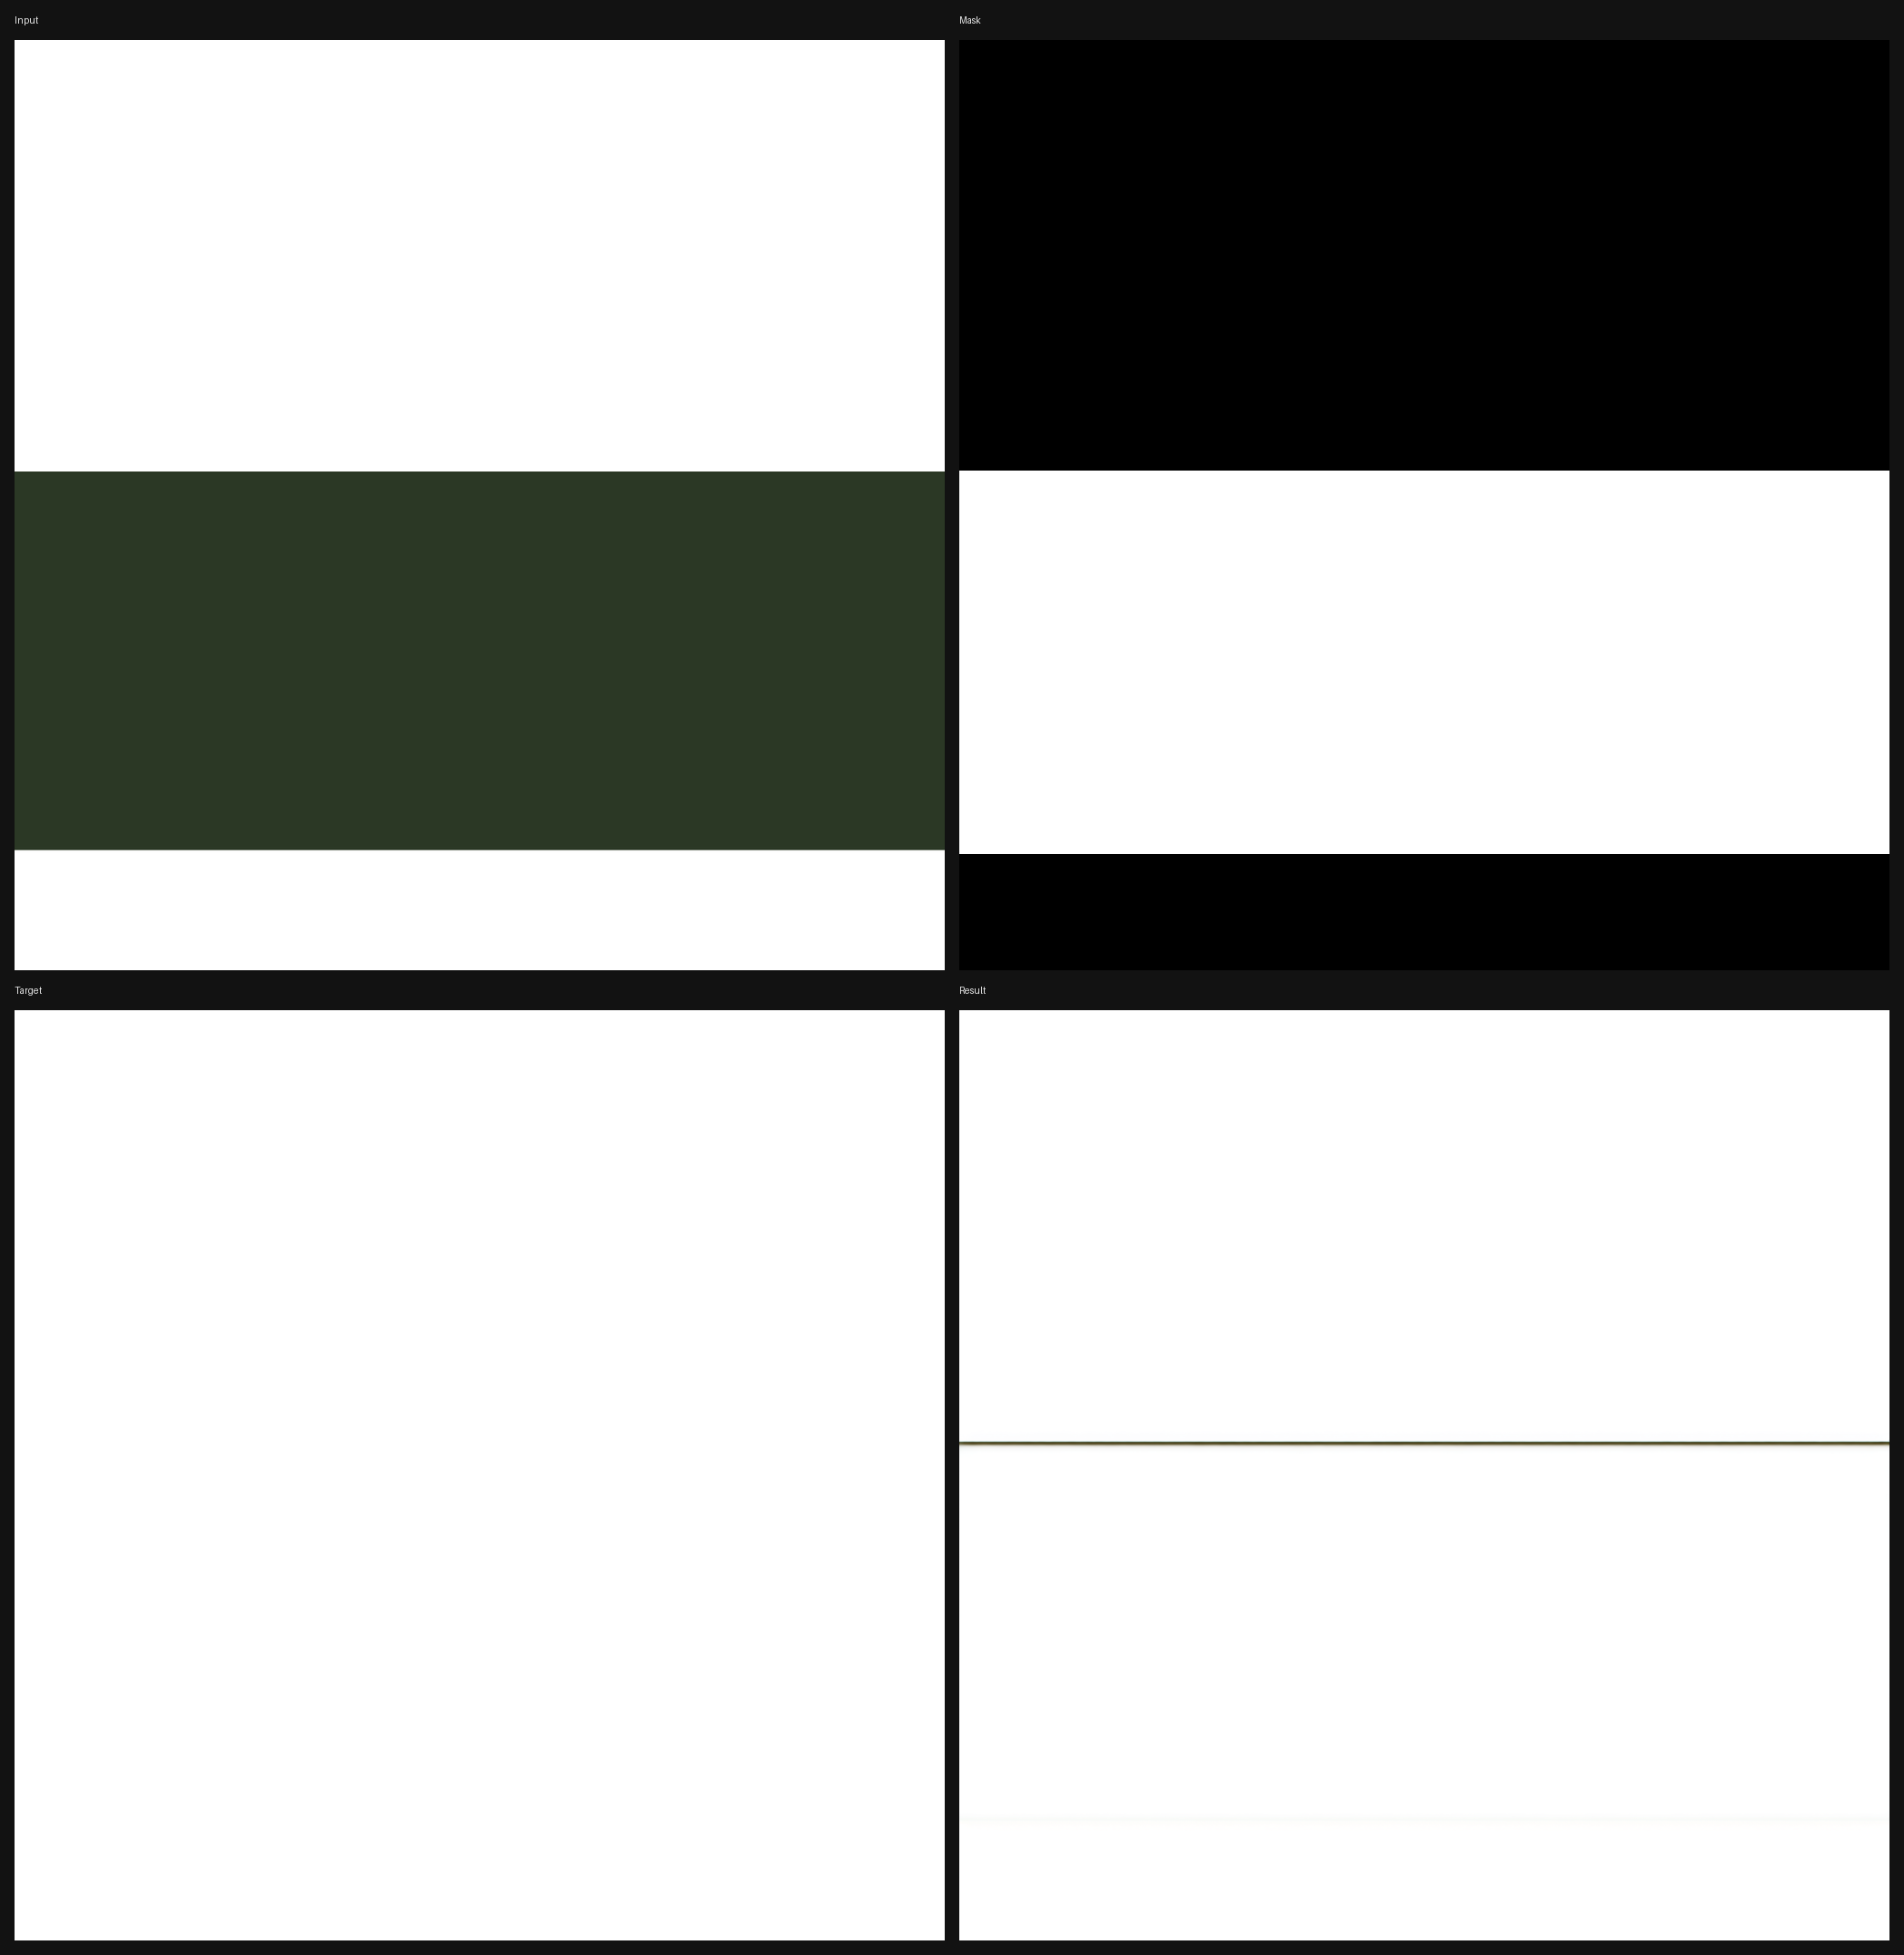

In [8]:
from PIL import ImageOps, ImageDraw


def resize_by_max_long_side(image, max_long_side, resample):
    if max_long_side is None:
        return image
    width, height = image.size
    long_side = max(width, height)
    if long_side <= max_long_side:
        return image
    scale = max_long_side / float(long_side)
    new_size = (
        max(1, int(round(width * scale))),
        max(1, int(round(height * scale))),
    )
    return image.resize(new_size, resample)


input_image = Image.open(INPUT_IMAGE_PATH).convert("RGB")
inpaint_mask = Image.open(MASK_IMAGE_PATH).convert("RGB")
target_image = Image.open(TARGET_IMAGE_PATH).convert("RGB") if TARGET_IMAGE_PATH.exists() else None

max_long_side = globals().get("MAX_LONG_SIDE", globals().get("RESIZE_TO", 1024))
input_image = resize_by_max_long_side(input_image, max_long_side, Image.LANCZOS)
inpaint_mask = resize_by_max_long_side(inpaint_mask, max_long_side, Image.NEAREST)
if target_image is not None:
    target_image = resize_by_max_long_side(target_image, max_long_side, Image.LANCZOS)

if inpaint_mask.size != input_image.size:
    inpaint_mask = inpaint_mask.resize(input_image.size, Image.NEAREST)
if target_image is not None and target_image.size != input_image.size:
    target_image = target_image.resize(input_image.size, Image.LANCZOS)

generated_result = pipe(
    PROMPT,
    negative_prompt=NEGATIVE_PROMPT,
    cfg_scale=CFG_SCALE,
    seed=SEED,
    input_image=input_image,
    inpaint_mask=inpaint_mask,
    blockwise_controlnet_inputs=[ControlNetInput(image=input_image, inpaint_mask=inpaint_mask)],
    height=input_image.size[1],
    width=input_image.size[0],
    num_inference_steps=NUM_INFERENCE_STEPS,
)

output_dir = Path("/home/ubuntu/DiffSynth-Studio/output/qwen_blockwise_controlnet_inpaint")
output_dir.mkdir(parents=True, exist_ok=True)
output_name = f"val_{VAL_SAMPLE_INDEX:05d}_{TRAINED_CONTROLNET_PATH.stem}.png"
output_path = output_dir / output_name
generated_result.save(output_path)


def make_panel(image, title, panel_size, mask_mode=False):
    panel = Image.new("RGB", panel_size, (32, 32, 32))
    if image is not None:
        if mask_mode:
            image = ImageOps.colorize(image.convert("L"), black=(0, 0, 0), white=(255, 255, 255))
        else:
            image = image.convert("RGB")
        image = ImageOps.contain(image, panel_size, Image.LANCZOS)
        x = (panel_size[0] - image.size[0]) // 2
        y = (panel_size[1] - image.size[1]) // 2
        panel.paste(image, (x, y))
    return {"title": title, "panel": panel}


panel_w = max(
    input_image.size[0],
    generated_result.size[0],
    target_image.size[0] if target_image is not None else 0,
)
panel_h = max(
    input_image.size[1],
    generated_result.size[1],
    target_image.size[1] if target_image is not None else 0,
)
panel_size = (panel_w, panel_h)

panels = [
    make_panel(input_image, "Input", panel_size),
    make_panel(inpaint_mask, "Mask", panel_size, mask_mode=True),
    make_panel(target_image, "Target" if target_image is not None else "Target (N/A)", panel_size),
    make_panel(generated_result, "Result", panel_size),
]

label_h = 28
pad = 16
grid_cols = 2
grid_rows = 2
preview_w = pad + grid_cols * (panel_size[0] + pad)
preview_h = pad + grid_rows * (label_h + panel_size[1] + pad)
preview = Image.new("RGB", (preview_w, preview_h), (18, 18, 18))
draw = ImageDraw.Draw(preview)

for idx, item in enumerate(panels):
    row, col = divmod(idx, grid_cols)
    x = pad + col * (panel_size[0] + pad)
    y = pad + row * (label_h + panel_size[1] + pad)
    draw.text((x, y), item["title"], fill=(230, 230, 230))
    preview.paste(item["panel"], (x, y + label_h))

preview_output_path = output_dir / f"val_{VAL_SAMPLE_INDEX:05d}_{TRAINED_CONTROLNET_PATH.stem}_preview.png"
preview.save(preview_output_path)

print(f"[saved] {output_path}")
print(f"[saved preview] {preview_output_path}")
result = preview
display(result)

100%|██████████| 40/40 [00:21<00:00,  1.87it/s]


[saved full-regenerate] /home/ubuntu/DiffSynth-Studio/output/qwen_blockwise_controlnet_inpaint/val_00001_step-30000_fullreg.png


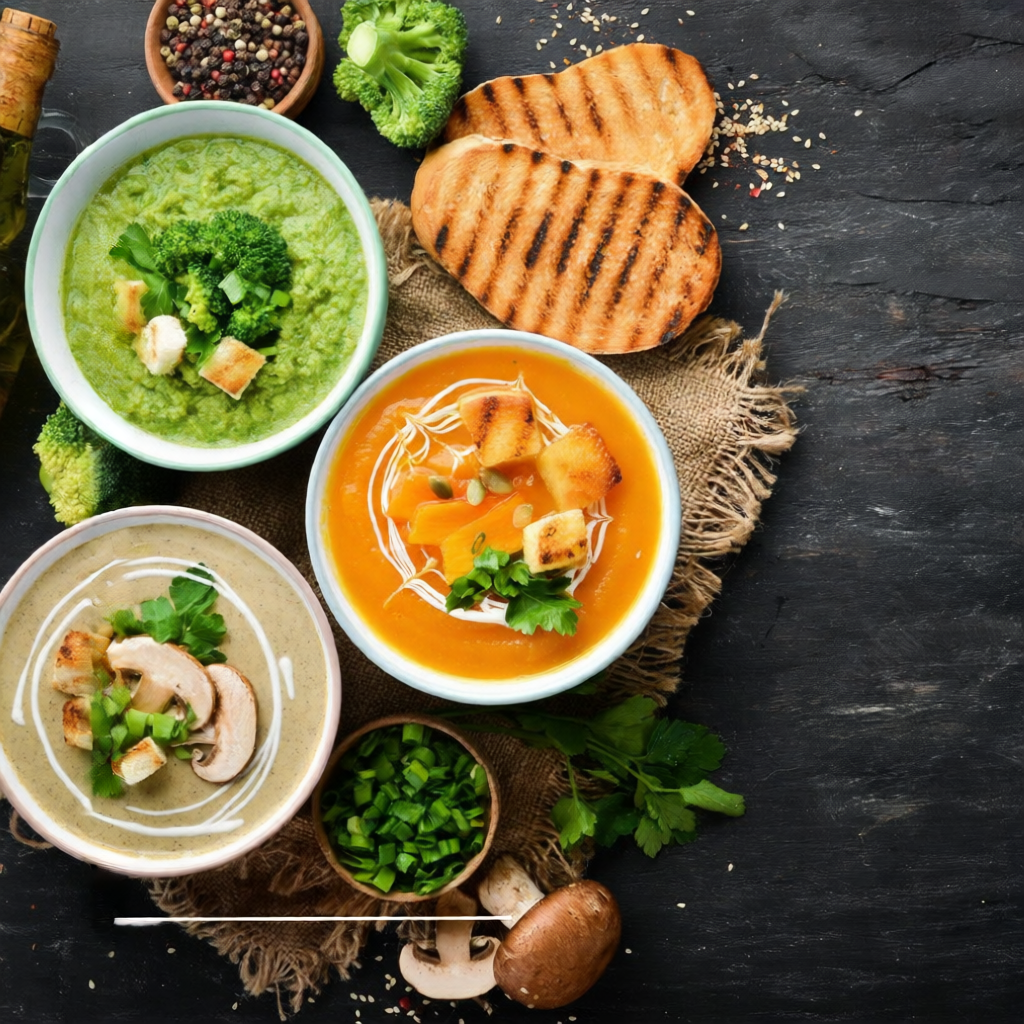

In [3]:
# Full-regenerate inference (no hard preserve outside mask)
# - Do NOT pass top-level input_image / inpaint_mask.
# - Keep Blockwise-ControlNet inpaint condition only.

from pathlib import Path
from PIL import Image


def resize_by_max_long_side(image, max_long_side, resample):
    if max_long_side is None or max(image.size) <= max_long_side:
        return image
    scale = max_long_side / max(image.size)
    new_size = (
        max(1, int(round(image.size[0] * scale))),
        max(1, int(round(image.size[1] * scale))),
    )
    return image.resize(new_size, resample)


input_image = Image.open(INPUT_IMAGE_PATH).convert("RGB")
inpaint_mask = Image.open(MASK_IMAGE_PATH).convert("RGB")

max_long_side = globals().get("MAX_LONG_SIDE", globals().get("RESIZE_TO", 1024))
input_image = resize_by_max_long_side(input_image, max_long_side, Image.LANCZOS)
inpaint_mask = resize_by_max_long_side(inpaint_mask, max_long_side, Image.NEAREST)
if inpaint_mask.size != input_image.size:
    inpaint_mask = inpaint_mask.resize(input_image.size, Image.NEAREST)

generated_result_fullreg = pipe(
    PROMPT,
    negative_prompt=NEGATIVE_PROMPT,
    cfg_scale=CFG_SCALE,
    seed=SEED,
    blockwise_controlnet_inputs=[ControlNetInput(image=input_image, inpaint_mask=inpaint_mask)],
    height=input_image.size[1],
    width=input_image.size[0],
    num_inference_steps=NUM_INFERENCE_STEPS,
)

output_dir = Path("/home/ubuntu/DiffSynth-Studio/output/qwen_blockwise_controlnet_inpaint")
output_dir.mkdir(parents=True, exist_ok=True)
output_name_fullreg = f"val_{VAL_SAMPLE_INDEX:05d}_{TRAINED_CONTROLNET_PATH.stem}_fullreg.png"
output_path_fullreg = output_dir / output_name_fullreg
generated_result_fullreg.save(output_path_fullreg)

print(f"[saved full-regenerate] {output_path_fullreg}")
display(generated_result_fullreg)

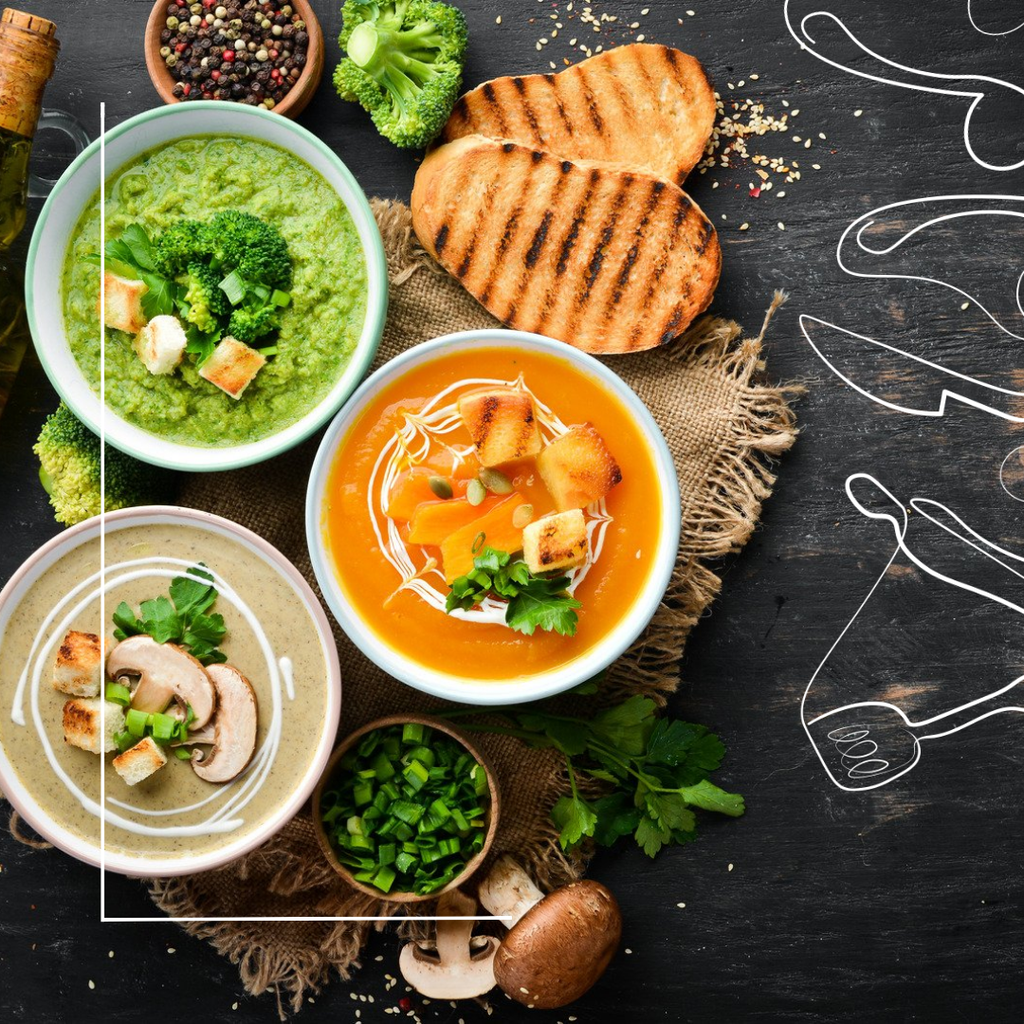

In [4]:
input_image

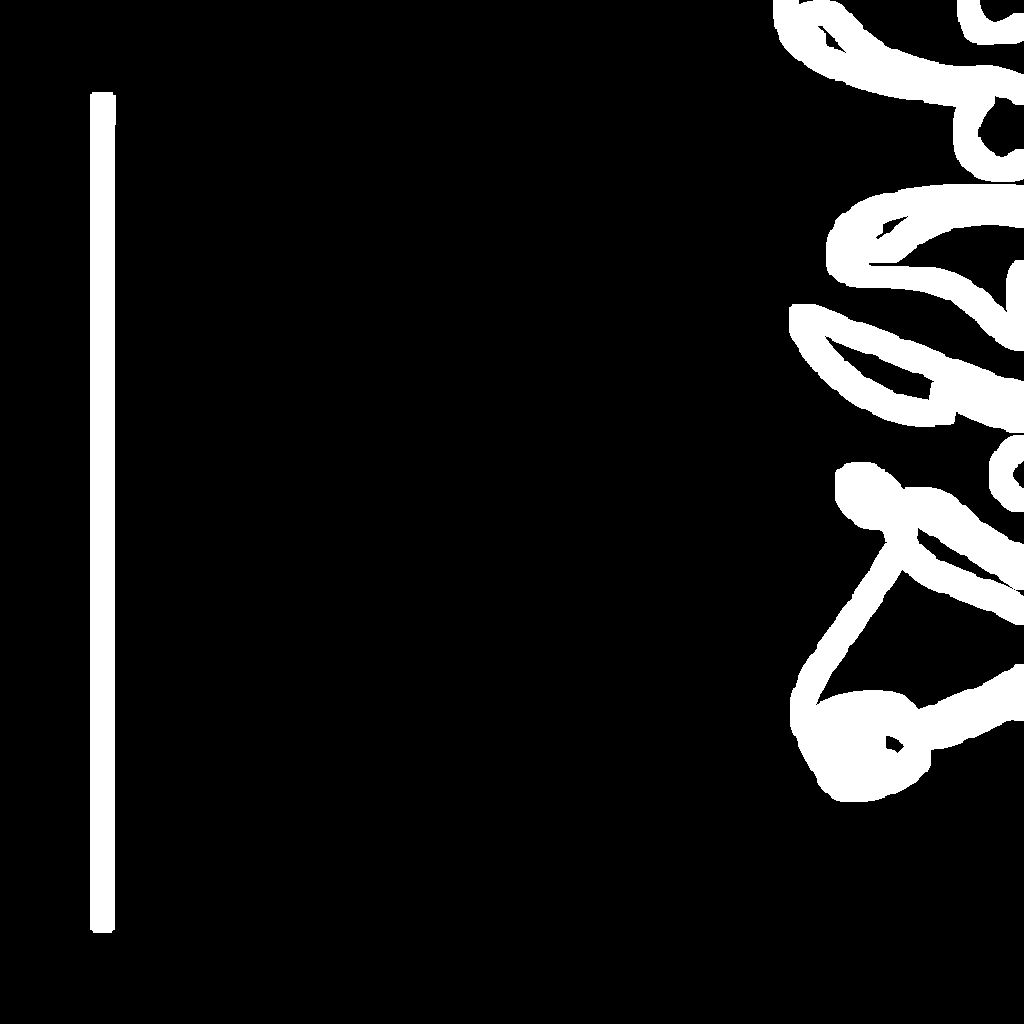

In [6]:
inpaint_mask